## Access Vessel Bio Optical Suspended Particulate Matter Data (Parquet)

This notebook accesses **in-situ Suspended Particulate Matter (SPM)** measurements from the
[IMOS Bio-Optical Database of Australian Waters (BODBAW)](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/97b9fe73-ee44-437f-b2ae-5b8613f81042)
and produces the visualisations most commonly used in ocean-colour and coastal oceanography.

### About the dataset
SPM (also called Total Suspended Matter, TSM) quantifies the concentration of all solid particulates
in the water column. It is a primary driver of light attenuation and a key satellite-validation target.

| Column | Units | Description |
|---|---|---|
| `SPM` | mg L⁻¹ | Total Suspended Particulate Material (= SPM_inorg + SPM_org) |
| `SPM_inorg` | mg L⁻¹ | Inorganic fraction — mineral sediment, lithogenic particles (available in subset of files) |
| `SPM_org` | mg L⁻¹ | Organic fraction — phytoplankton, detritus, fecal pellets (available in subset of files) |
| `DEPTH` | m | Measurement depth |

**Oceanographic significance:**
- High SPM near the surface → phytoplankton bloom or river plume
- High SPM near the bottom → sediment resuspension by currents/waves
- High SPM_inorg fraction → river-dominated or resuspension regime
- High SPM_org fraction → biologically productive, clear water

📌 Source maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/blob/main/notebooks/vessel_bio_optical_suspended_matter_delayed_qc.ipynb)


In [1]:
dataset_name = "vessel_bio_optical_suspended_matter_delayed_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 45ms
Checked 155 packages in 1ms


✅ Virtual environment already exists, skipping creation.
✅ Local version 0.3.13 is up to date (remote: 0.3.13)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4063: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 13.7 ms, sys: 1.24 ms, total: 14.9 ms
Wall time: 13.7 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [6]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 2.43 ms, sys: 193 µs, total: 2.62 ms
Wall time: 1.52 ms


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


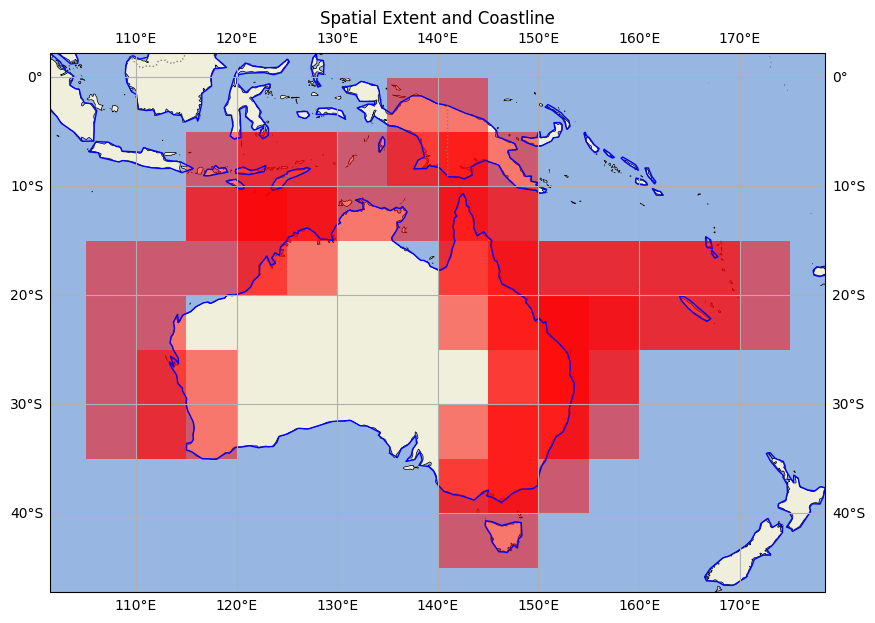

In [7]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 109 ms, sys: 101 ms, total: 209 ms
Wall time: 360 ms


(Timestamp('1997-02-14 17:11:00'), Timestamp('2024-07-31 00:12:00.000000256'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-04-29 10:32:32,293 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/vessel_bio_optical_suspended_matter_delayed_qc.parquet


{'timestamp': {'type': 'int64',
  'units': '1',
  'long_name': 'Partition timestamp'},
 'polygon': {'type': 'string',
  'units': '1',
  'long_name': 'Spatial partition polygon'},
 'filename': {'type': 'string',
  'units': '1',
  'long_name': 'Filename of the source file'},
 'TIME': {'type': 'timestamp[ns]',
  'axis': 'T',
  'long_name': 'time',
  'standard_name': 'time'},
 'LATITUDE': {'type': 'float',
  'axis': 'Y',
  'long_name': 'latitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'latitude',
  'units': 'degrees_north',
  'valid_max': 90.0,
  'valid_min': -90.0},
 'LONGITUDE': {'type': 'float',
  'axis': 'X',
  'long_name': 'longitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'longitude',
  'units': 'degrees_east',
  'valid_max': 180.0,
  'valid_min': -180.0},
 'DEPTH': {'type': 'float',
  'axis': 'Z',
  'long_name': 'depth',
  'positive': 'down',
  'reference_datum': 'sea surface',
  'standar

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [10]:
%%time
df = aodn_dataset.get_data(#date_start='1994-01-01',
                           #date_end='2023-12-31',
                           lat_min=-45,
                           lat_max=-10,
                           lon_min=110,
                           lon_max=160,
                           )

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Unique profiles (TIME × station_name): {df.groupby(['TIME','station_name']).ngroups}")
print(f"SPM  — non-null: {df['SPM'].notna().sum():,}  range: {df['SPM'].min():.3f}–{df['SPM'].max():.3f} mg L⁻¹")
print(f"SPM_inorg — non-null: {df['SPM_inorg'].notna().sum():,}")
print(f"SPM_org   — non-null: {df['SPM_org'].notna().sum():,}")
df.head(3)


2026-04-29 10:32:41,916 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/vessel_bio_optical_suspended_matter_delayed_qc.parquet


Rows: 8,994  |  Columns: 11
Unique profiles (TIME × station_name): 6763
SPM  — non-null: 8,991  range: 0.000–580.000 mg L⁻¹
SPM_inorg — non-null: 2,287
SPM_org   — non-null: 2,287
CPU times: user 1.3 s, sys: 185 ms, total: 1.49 s
Wall time: 9.62 s


,filename,TIME,LATITUDE,LONGITUDE,DEPTH,station_name,SPM,SPM_inorg,SPM_org,timestamp,polygon
0,IMOS_SRS-OC-BODBAW_X_19970225T014500Z_GBR_CNS_...,2002-03-11 20:30:00,-16.112333,145.484161,0.0,CNS882,1.480,NaN,NaN,1009843200,0103000000010000000500000000000000008061400000...
1,IMOS_SRS-OC-BODBAW_X_19970225T014500Z_GBR_CNS_...,2002-03-11 21:44:00,-16.235666,145.514496,0.0,CNS883,1.295,NaN,NaN,1009843200,0103000000010000000500000000000000008061400000...
2,IMOS_SRS-OC-BODBAW_X_19970225T014500Z_GBR_CNS_...,2002-03-11 22:33:00,-16.320833,145.471664,0.0,CNS884,1.830,NaN,NaN,1009843200,0103000000010000000500000000000000008061400000...


In [11]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


#df.aodn.download_as_csv()

## Create a TIME and scalar/number filter

This cell filters the dataset by time range and a scalar value (from a Parquet partition) using the `scalar_filter` argument.  
This leverages Parquet partitioning to apply efficient, server-side filtering, which significantly speeds up data loading.

## Spatial Distribution of Surface SPM

Surface SPM (depth ≤ 5 m) plotted on an Australian coastal map.
Colour scale is **logarithmic** because SPM spans ~3 orders of magnitude (0.1–100 mg L⁻¹):
- Blue (< 1 mg L⁻¹): optically clear, offshore waters
- Red/orange (> 5 mg L⁻¹): turbid coastal/estuarine waters with strong light attenuation


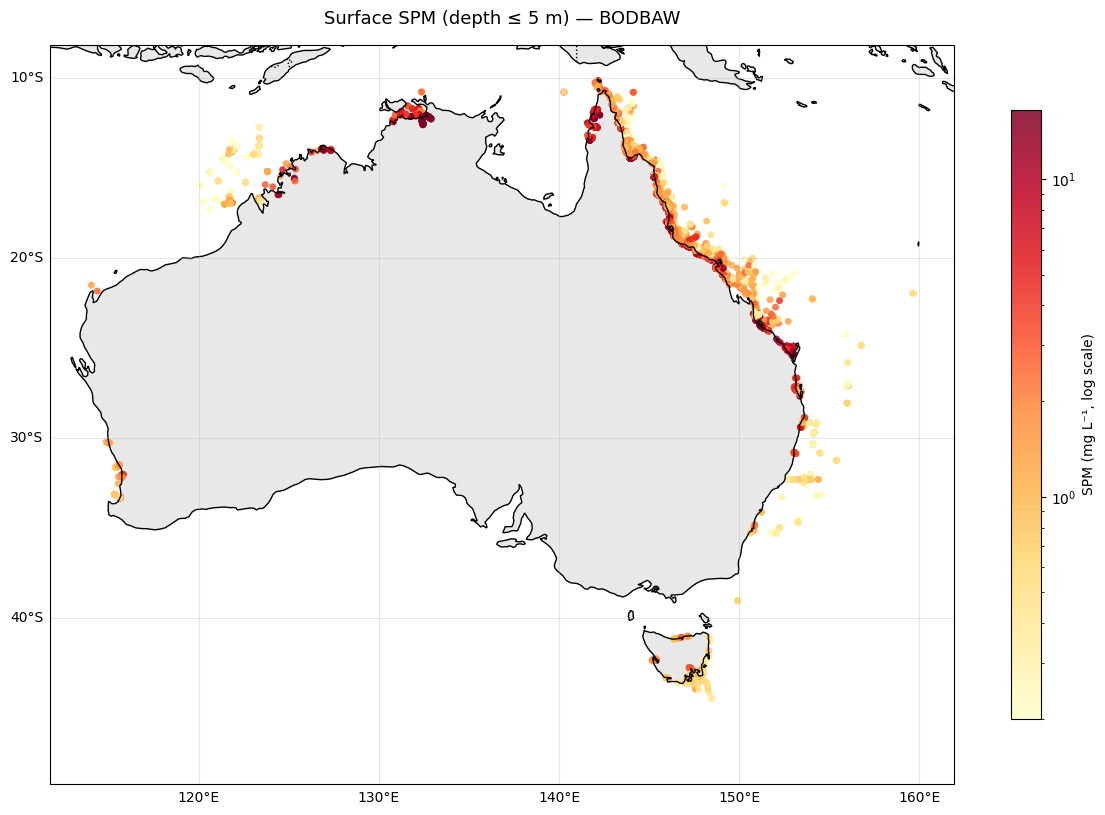

n = 7,883 surface observations  |  median SPM = 2.00 mg L⁻¹


In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

df_surf = df[df['DEPTH'] <= 5].dropna(subset=['SPM', 'LATITUDE', 'LONGITUDE']).copy()
df_surf = df_surf[df_surf['SPM'] > 0]

if df_surf.empty:
    print("No surface SPM data in the filtered region.")
else:
    fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': ccrs.PlateCarree()})

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    sc = ax.scatter(df_surf['LONGITUDE'], df_surf['LATITUDE'],
                    c=df_surf['SPM'],
                    norm=mcolors.LogNorm(vmin=df_surf['SPM'].quantile(0.05).clip(0.01),
                                         vmax=df_surf['SPM'].quantile(0.95)),
                    cmap='YlOrRd', s=25, alpha=0.85, edgecolors='none',
                    transform=ccrs.PlateCarree())

    plt.colorbar(sc, ax=ax, label='SPM (mg L⁻¹, log scale)', shrink=0.7, pad=0.05)

    lon_pad = max((df_surf['LONGITUDE'].max() - df_surf['LONGITUDE'].min()) * 0.05, 2)
    lat_pad = max((df_surf['LATITUDE'].max()  - df_surf['LATITUDE'].min())  * 0.05, 2)
    ax.set_extent([df_surf['LONGITUDE'].min() - lon_pad, df_surf['LONGITUDE'].max() + lon_pad,
                   df_surf['LATITUDE'].min()  - lat_pad, df_surf['LATITUDE'].max()  + lat_pad])

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title('Surface SPM (depth ≤ 5 m) — BODBAW', fontsize=13, pad=15)
    plt.tight_layout()
    plt.show()
    print(f"n = {len(df_surf):,} surface observations  |  median SPM = {df_surf['SPM'].median():.2f} mg L⁻¹")


## SPM Depth Profiles

How SPM varies with depth reveals the dominant physical processes:
- **Surface maximum** → phytoplankton bloom or river input
- **Uniform profile** → well-mixed water column (wind-driven)
- **Bottom increase** → sediment resuspension by tidal currents or internal waves

Individual profiles are shown as thin translucent lines; the **bin-median profile** (5 m bins)
is the thick coloured line.


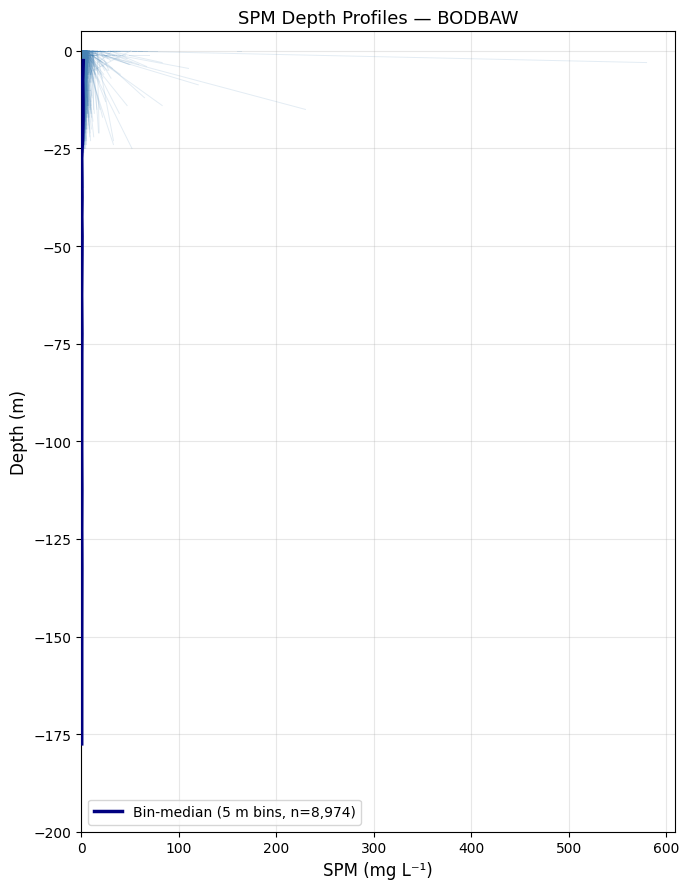

In [13]:
import matplotlib.pyplot as plt
import numpy as np

df_dp = df.dropna(subset=['SPM']).copy()
df_dp = df_dp[(df_dp['DEPTH'] >= 0) & (df_dp['DEPTH'] <= 200) & (df_dp['SPM'] > 0)]

fig, ax = plt.subplots(figsize=(7, 9))

for _, grp in df_dp.groupby(['TIME', 'station_name']):
    grp = grp.sort_values('DEPTH')
    if len(grp) < 2:
        continue
    ax.plot(grp['SPM'], -grp['DEPTH'], color='steelblue', alpha=0.15, linewidth=0.7)

# Bin-median profile (5 m bins)
df_dp['depth_bin'] = (df_dp['DEPTH'] // 5) * 5 + 2.5
med_prof = df_dp.groupby('depth_bin')['SPM'].median()
ax.plot(med_prof.values, -med_prof.index, color='navy', linewidth=2.5,
        label=f'Bin-median (5 m bins, n={len(df_dp):,})', zorder=5)

ax.set_xlabel('SPM (mg L⁻¹)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('SPM Depth Profiles — BODBAW', fontsize=13)
ax.set_ylim(-200, 5)
ax.set_xlim(left=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Inorganic vs Organic Fraction Decomposition

When available, `SPM_inorg` and `SPM_org` reveal the **particle origin**:

- **Inorganic-dominated** (SPM_inorg/SPM > 0.5): mineral-rich; river plumes, sediment
  resuspension, aeolian dust — typical in coastal and shelf waters
- **Organic-dominated** (SPM_org/SPM > 0.5): biologically active; offshore productive waters,
  phytoplankton blooms

The scatter plot shows individual observations; the pie chart shows the median partitioning.


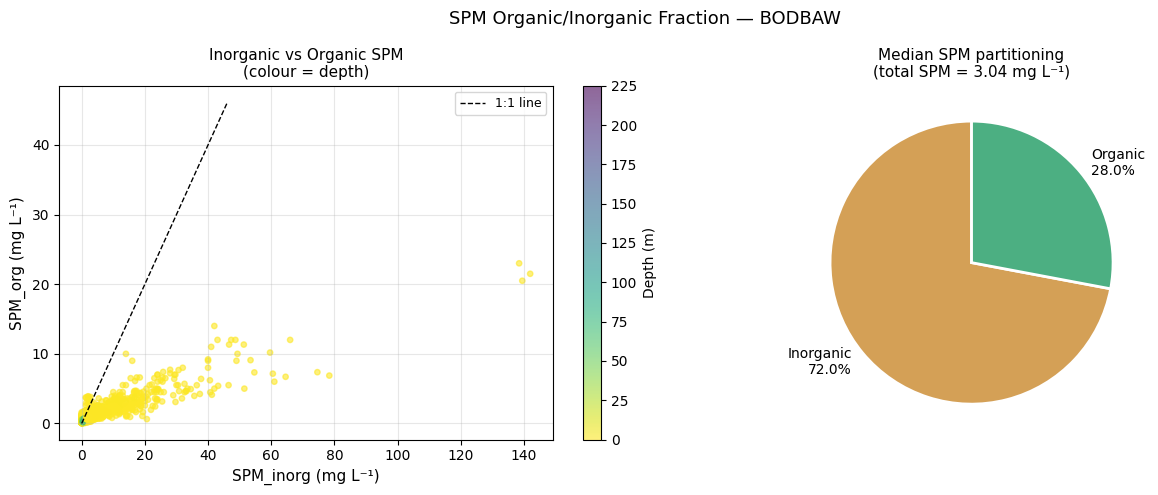

n = 2,286 observations with both fractions
Median fraction: 72.0% inorganic, 28.0% organic


In [14]:
import matplotlib.pyplot as plt
import numpy as np

df_frac = df.dropna(subset=['SPM_inorg', 'SPM_org', 'SPM']).copy()
df_frac = df_frac[df_frac['SPM'] > 0]

if df_frac.empty:
    print("SPM_inorg / SPM_org fractions are not available in this data subset.")
    print("These columns are only populated in a subset of BODBAW files.")
else:
    df_frac['f_inorg'] = (df_frac['SPM_inorg'] / df_frac['SPM']).clip(0, 1)
    df_frac['f_org']   = (df_frac['SPM_org']   / df_frac['SPM']).clip(0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Scatter: SPM_inorg vs SPM_org coloured by depth
    ax = axes[0]
    sc = ax.scatter(df_frac['SPM_inorg'], df_frac['SPM_org'],
                    c=df_frac['DEPTH'], cmap='viridis_r', s=15, alpha=0.6)
    plt.colorbar(sc, ax=ax, label='Depth (m)')
    # 1:1 line = equal fractions
    lim = max(df_frac['SPM_inorg'].quantile(0.99), df_frac['SPM_org'].quantile(0.99)) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
    ax.set_xlabel('SPM_inorg (mg L⁻¹)', fontsize=11)
    ax.set_ylabel('SPM_org (mg L⁻¹)', fontsize=11)
    ax.set_title('Inorganic vs Organic SPM\n(colour = depth)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Pie chart: median fractions
    ax2 = axes[1]
    med_inorg = df_frac['SPM_inorg'].median()
    med_org   = df_frac['SPM_org'].median()
    total     = med_inorg + med_org
    sizes  = [med_inorg / total * 100, med_org / total * 100]
    labels = [f'Inorganic\n{sizes[0]:.1f}%', f'Organic\n{sizes[1]:.1f}%']
    colors = ['#d4a056', '#4caf82']
    wedges, texts = ax2.pie(sizes, labels=labels, colors=colors, startangle=90,
                             wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax2.set_title(f'Median SPM partitioning\n(total SPM = {total:.2f} mg L⁻¹)', fontsize=11)

    fig.suptitle('SPM Organic/Inorganic Fraction — BODBAW', fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"n = {len(df_frac):,} observations with both fractions")
    print(f"Median fraction: {sizes[0]:.1f}% inorganic, {sizes[1]:.1f}% organic")


## Temporal Variability of Surface SPM

Surface SPM (depth ≤ 5 m) grouped by **year** to show long-term trends, and by **month**
to reveal seasonal cycles.

Australian coastal SPM often shows:
- **Summer peaks** in tropical/northern waters (wet season river input, cyclone-driven resuspension)
- **Winter peaks** in southern waters (storm-driven resuspension, winter mixing)
- **Inter-annual variability** linked to ENSO, flood events, and sampling effort


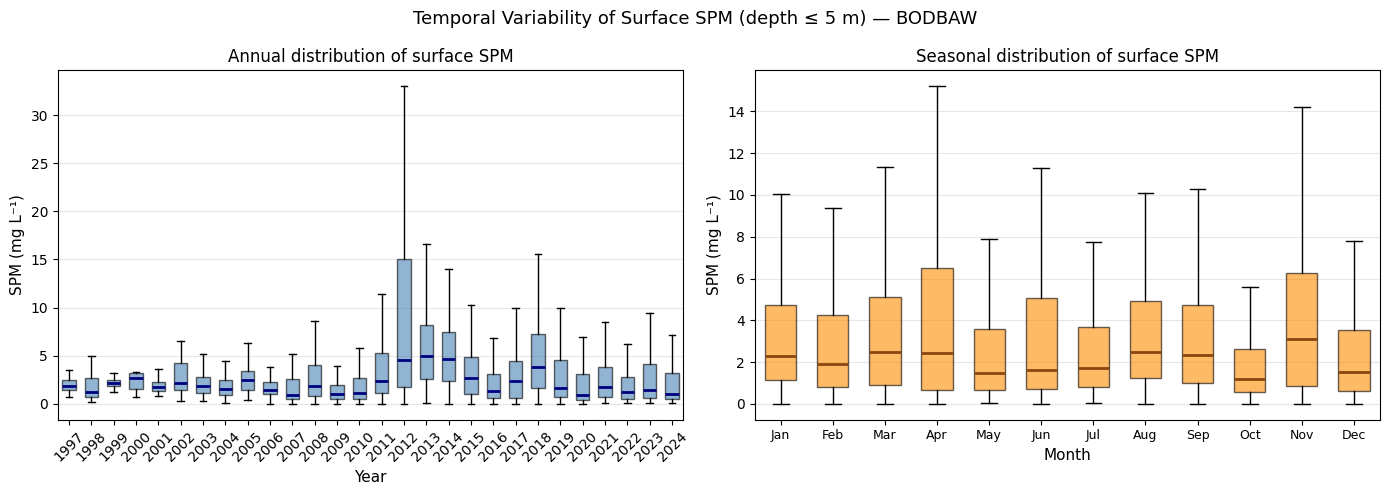

n = 7,883  |  28 years  |  median = 2.00 mg L⁻¹


In [15]:
import matplotlib.pyplot as plt
import numpy as np

df_ts = df[(df['DEPTH'] <= 5)].dropna(subset=['SPM']).copy()
df_ts = df_ts[df_ts['SPM'] > 0]
df_ts['year']  = df_ts['TIME'].dt.year
df_ts['month'] = df_ts['TIME'].dt.month

if df_ts.empty:
    print("No surface SPM data available.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── By year ──────────────────────────────────────────────────────────────
    ax = axes[0]
    years = sorted(df_ts['year'].unique())
    data_by_year = [df_ts[df_ts['year'] == y]['SPM'].values for y in years]
    bp = ax.boxplot(data_by_year, positions=years, widths=0.6,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='navy', linewidth=2))
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('SPM (mg L⁻¹)', fontsize=11)
    ax.set_title('Annual distribution of surface SPM', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', alpha=0.3)

    # ── By month ─────────────────────────────────────────────────────────────
    ax2 = axes[1]
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    data_by_month = [df_ts[df_ts['month'] == m]['SPM'].values for m in range(1, 13)]
    bp2 = ax2.boxplot(data_by_month, positions=range(1, 13), widths=0.6,
                      patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='darkorange', alpha=0.6),
                      medianprops=dict(color='saddlebrown', linewidth=2))
    ax2.set_xticks(range(1, 13))
    ax2.set_xticklabels(month_names, fontsize=9)
    ax2.set_xlabel('Month', fontsize=11)
    ax2.set_ylabel('SPM (mg L⁻¹)', fontsize=11)
    ax2.set_title('Seasonal distribution of surface SPM', fontsize=12)
    ax2.grid(True, axis='y', alpha=0.3)

    fig.suptitle('Temporal Variability of Surface SPM (depth ≤ 5 m) — BODBAW', fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"n = {len(df_ts):,}  |  {len(years)} years  |  median = {df_ts['SPM'].median():.2f} mg L⁻¹")
